# TP2 - Expectation Maximization Algorithm - Importance Sampling  
**Computational Statistics (MVA 2025-2026)**  
**École Normale Supérieure Paris-Saclay**

**Student:** Yannaël Bossard  
**Email:** yannael.bossard@ens-paris-saclay.fr  
**Date:** 02 November 2025  
**Deadline:** 7 / 11 / 2025 - 23 h 59  
link of the Colab: https://colab.research.google.com/drive/1BpYpJaRaznsmeY6zplenhH1sD8sG8gqW?usp=sharing



### Objective:
This practical session introduces the concept of Expectation-Maximization algorithm, and illustrates the important of sampling.

In [1]:
# libraries
#%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import adjusted_rand_score
import sys, os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

seed = 13
np.random.seed(seed) # for reproduction

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Exercice 1: Discrete distributions



#### Question1:

With the **Inverse Transform Sampling** method, we can use a uniform random variable $U \sim \mathrm{Unif}[0,1]$, and generate a new variable $X$ with a given CDF $F_X(x)$ by setting $$X = F_X^{-1}(U).$$

This comes from:
$$
F_X(x)
= \Pr(X \le x)
= \Pr(T(U) \le x)
= \Pr(U \le T^{-1}(x))
= T^{-1}(x), \quad \text{for } x \in \mathbb{R}$$ and with $T : [0,1] \mapsto \mathbb{R}$ s.t.  $T(U) \overset{d}{=} X$.




**Discrete Version:**
In the discrete case, the same principle applies:  
the discrete CDF $F(k)$ replaces the continuous one, and the inverse is implemented by locating the interval of $U$.


$$
F(k) = \sum_{j=1}^{k} \pi_j, \quad k = 1, \ldots, K,
$$


Hence, we want to


1.   Generate a uniform random variable (we assume python function np.random.rand()
2.   Find the smallest index $k$ s.t. $$F(k-1) < U < F(k)$$ (since the probability of U included in the interval is $\pi_k$
3.   Return Y being $v_k$







#### Question2&3:

We demonstrated the algorithm functioning using K=4, any K can be used, by small K is hand-convenient

**Summary:** Using methods from question 1, we empirically demonstrated that we can indeed use inverse transform sampling principles to generate random numbers from any probability distribution, just by assuming that we can generate uniform random variables.

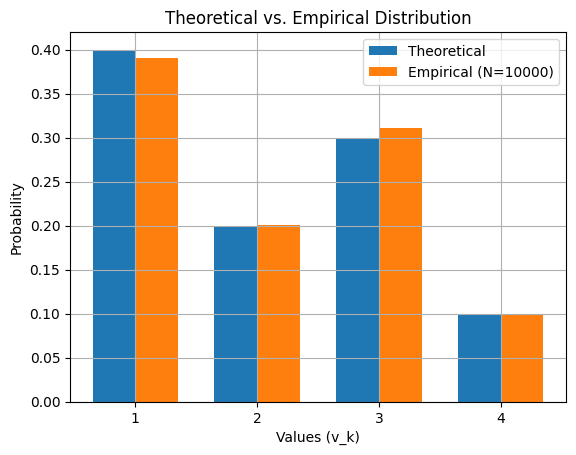

In [3]:


def generate_discrete_distr(v,pi):
  '''
  Generate a random variable Y that follows a discrete distribution supported on v
  with probabilities pi as explained in question1
  '''

  cumul_pi = np.cumsum(pi)
  u = np.random.rand(1) # scalar random value from uniform distribution

  look_for_zero = cumul_pi-u # list assumed to be sorted, piecewisly increasing
  idx_nonzero = 0
  pointer_zero = look_for_zero[idx_nonzero]
  while pointer_zero < 0 and idx_nonzero < len(look_for_zero):
    idx_nonzero += 1
    pointer_zero = look_for_zero[idx_nonzero]

  return v[idx_nonzero]


N = 10000 # samples
v = np.array([1,2,3,4])
pi = np.array([0.4, 0.2, 0.3, 0.1])
K = len(pi)

# Generate a sequence of samples from the given distribution
Y = [generate_discrete_distr(v, pi) for _ in range(N)]


# Visualization
unique, counts = np.unique(Y, return_counts=True)
#print("unique = ", unique,"counts = ", counts)
empir_proba = counts/N

xx = np.arange(K)
width = 0.35
fig, ax = plt.subplots()
rects1 = ax.bar(xx - width/2, pi, width, label='Theoretical')
rects2 = ax.bar(xx + width/2, empir_proba, width, label=f'Empirical (N={N})')
ax.set_ylabel('Probability')
ax.set_title('Theoretical vs. Empirical Distribution')
ax.set_xticks(xx)
ax.set_xticklabels(v)
ax.set_xlabel('Values (v_k)')
ax.legend()
ax.grid()
plt.show()





## Exercice 2: Gaussian mixture model and the EM algorithm

#### Question1:

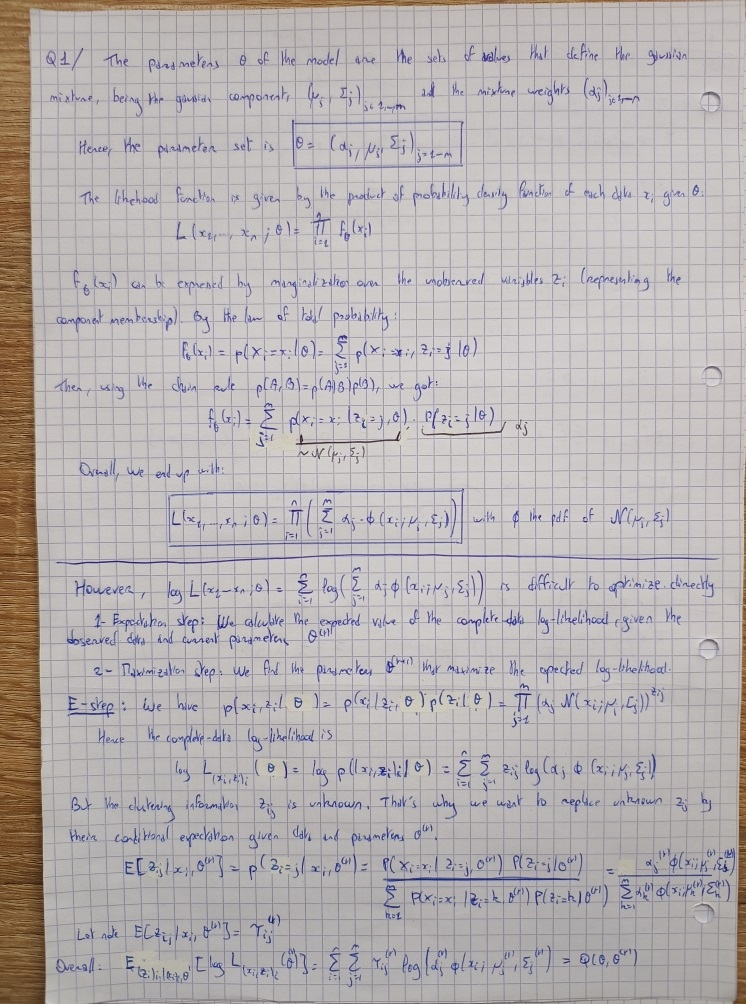

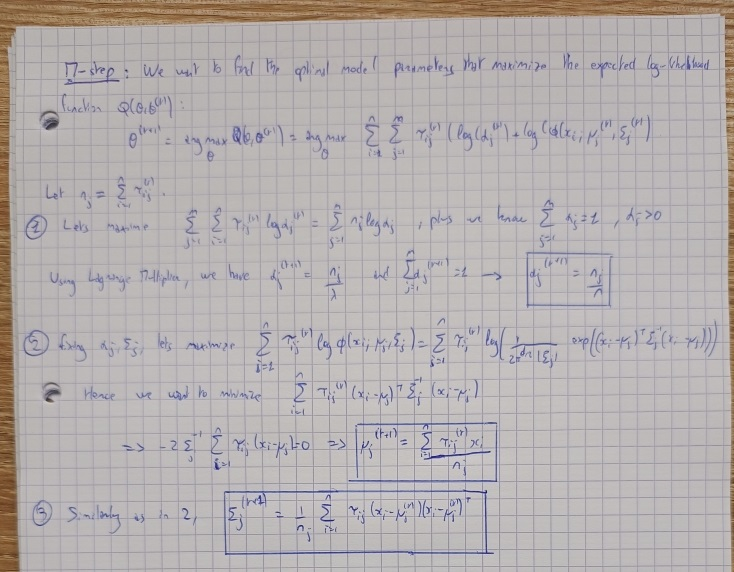

#### Question2:

**Summary:** I used results from question 1 to generate the mixture weights α (3 dense, distinct, clusters) and *np.random.multivariate_normal* to generate samples from 2D multivariate gaussian components.

/tmp/ipython-input-3336328710.py:17: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  Xs[i] = np.random.multivariate_normal(mean=mus[z_i], cov=sigmas[z_i], size=1) # X_i | Z_i=j ~ N(mus[j], sigmas[j])


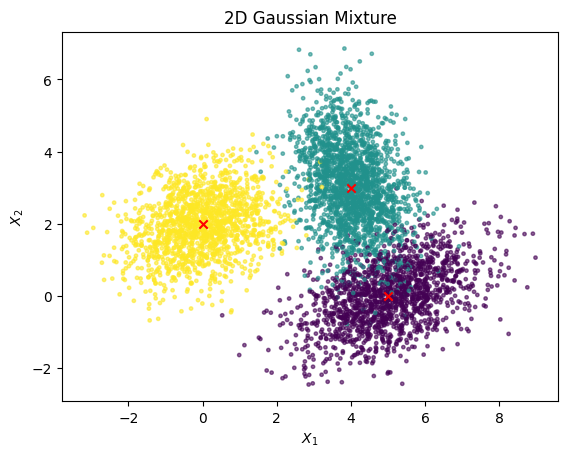

In [4]:
true_alphas = np.array([0.3,0.4, 0.3])
true_mus = np.array([[5, 0],[ 4, 3],[ 0, 2]])
true_sigmas = np.array([[[1.63, 0.7],[0.3, 0.71]],[[0.55, -0.21],[-0.29, 1.31]],[[0.88, 0.0],[0.5, 0.75]]])
K = len(true_alphas)

def draw_from_gmm(n, alphas, mus, sigmas):
  '''
  Generate samples following Gaussian Mixture Law
  '''
  m = len(alphas)
  Xs = np.zeros((n, 2))
  Z  = np.zeros(n)

  for i in range(n):
      z_i = generate_discrete_distr(np.arange(m), alphas) # cluster membership using Ex1 method
      Z[i] = z_i
      Xs[i] = np.random.multivariate_normal(mean=mus[z_i], cov=sigmas[z_i], size=1) # X_i | Z_i=j ~ N(mus[j], sigmas[j])

  return Xs, Z # data points, ground-truth xluster membership

n = 5000
X_samp, Z_samp = draw_from_gmm(n, true_alphas, true_mus, true_sigmas)

fig2 = plt.figure()
plt.scatter(X_samp[:,0], X_samp[:,1], c=Z_samp, cmap="viridis", s=6, alpha=0.6)
plt.scatter(true_mus[:,0],true_mus[:,1],marker="x",c='r')
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("2D Gaussian Mixture")
plt.show()


#### Question3:

**Summary:** The principle of the code (iterations of E-step + M-step) is detailed in the pictures from question 1.

I used stoppign criterion based on the variance of the last 5 log-likelihood. If variance is small, it means that we reached a plateau and can stop the loop (however, the threshold is obtained empirically).

We can see that the implemented EM algorithm achieve a good clustering performance (ARI>0.9 in a few tens of iterations (i used ARI because it's well known and permutation-invariant)). It reaches a plateau after ≃25 epochs, i tried to go beyond (>100 epochs), but it doesn't change much.







In [5]:
def gaussian_pdf(X, mu, sigma):
  '''
  Normal pdf called phi in the above sheet method
  '''
  n = len(X)
  return (2*np.pi)**(-n/2) * (np.linalg.det(sigma) ** (-1/2) ) * np.exp(-1/2*((X-mu).T@np.linalg.inv(sigma)@(X-mu)))


def E_step(X,alphas,mus,sigmas):
  '''
  Calculates the posterior tau_{ij}=P(z_i=j|x_i,teta)
  As explained in the above sheet method, we only need to compute tau_{ij} so that M_step will extract optimized model parameters
  '''
  n = len(X)
  m = len(alphas)
  tau = np.zeros((n,m))

  for i in range(n):
        x = X[i]
        num = []
        for j in range(m):
            p = alphas[j] * gaussian_pdf(x, mus[j], sigmas[j])
            num.append(p)
        for j in range(m):
          if sum(num) != 0:
            tau[i, j] = num[j] / sum(num)
          else:
            tau[i, j] = 1 / m

  return tau

def init_params(X, m, method="uniform"):
  '''
  Set initial parameters at step 0, so that we can execute E-step first
  '''

  if method == "kmean":
    raise NotImplementedError
  elif method == "uniform":
    n = len(X)
    d = len(X[0])
    alphas = np.ones(m) / m
    mus = [np.random.rand(d) for _ in range(m)]
    sigmas = [np.eye(d) for _ in range(m)]
  else:
    raise NotImplementedError

  return alphas, mus, sigmas



def M_step(X,tau):
  '''
  With new parameters, the log-likelihood can be track over iteration
  '''

  n = len(X)
  d = len(X[0])
  m = tau.shape[1]

  alphas = np.zeros(m)
  mus = [np.zeros(d) for _ in range(m)]
  sigmas = [np.zeros((d, d)) for _ in range(m)]


  for j in range(m):
    nj = np.sum(tau[:, j])
    alphas[j] = nj / n

    mu_j = np.zeros(d)
    for i in range(n):
        mu_j += tau[i, j] * X[i]
    mu_j /= nj
    mus[j] = mu_j

    sigma_j = np.zeros((d, d))
    for i in range(n):
        x_mu = X[i] - mu_j
        sigma_j += tau[i, j] * np.outer(x_mu, x_mu)
    sigma_j /= nj
    sigmas[j] = sigma_j

  return alphas, mus, sigmas


def predict_gmm_labels(X, alphas, mus, sigmas):
    '''
    Predict labels (being label_i=argmax(Zi)=argmax(tau[i,:])) for each data point using the gmm posterior from the previous E-step.
    '''
    tau = E_step(X, alphas, mus, sigmas)
    labels = np.argmax(tau, axis=1)
    return labels


def gmm_EM(X, m, true_labels=None, max_iter=10, tol=1):

  n, d = X.shape
  alphas, mus, sigmas = init_params(X, m)
  log_likelihoods = []
  std_loglikelihood = []
  ari_evol = []
  for itera in range(max_iter):
    tau = E_step(X, alphas, mus, sigmas)
    alphas, mus, sigmas = M_step(X, tau)

    # Assess clustering
    pred_labels = predict_gmm_labels(X, alphas, mus, sigmas)
    if true_labels is not None:
      ari = adjusted_rand_score(true_labels, pred_labels)
      ari_evol.append(ari)


    log_likelihood = 0
    for i in range(n):
        x = X[i]
        likelihood_i = 0
        for j in range(m):
            likelihood_i += alphas[j] * gaussian_pdf(x, mus[j], sigmas[j])
        log_likelihood += np.log(likelihood_i)

    log_likelihoods.append(log_likelihood)
    var_loglikelihood = np.nanstd(log_likelihoods[-5:])
    std_loglikelihood.append(var_loglikelihood)
    if itera > 5 and var_loglikelihood < tol:
      break

  return alphas, mus, sigmas, log_likelihoods,std_loglikelihood, ari_evol, pred_labels

true_labels = Z_samp.astype(int)
alphas, mus, sigmas, log_likelihoods, std_loglikelihood, ari_evol, pred_labels = gmm_EM(X_samp, m=3,true_labels=true_labels, max_iter=30)



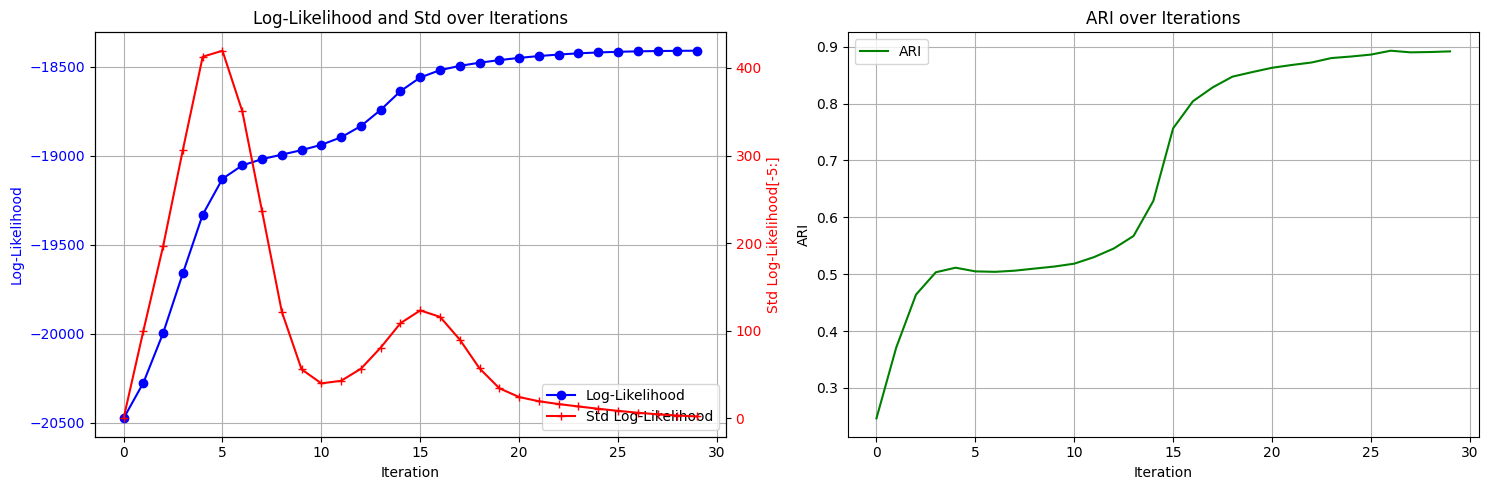

In [6]:
iterations = np.arange(len(log_likelihoods))

plt.figure(figsize=(15, 5))
# Loglikelihood & std(log_likelihoods[-5:])
ax1 = plt.subplot(1, 2, 1)
ln1 = ax1.plot(iterations, log_likelihoods, color='blue', marker='o', label='Log-Likelihood')
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Log-Likelihood", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)
ax2 = ax1.twinx()
ln2 = ax2.plot(iterations, std_loglikelihood, color='red', marker='+', label='Std Log-Likelihood')
ax2.set_ylabel("Std Log-Likelihood[-5:]", color='red')
ax2.tick_params(axis='y', labelcolor='red')
lns = ln1 + ln2
labels = [l.get_label() for l in lns]
ax1.legend(lns, labels, loc='lower right')

ax1.set_title("Log-Likelihood and Std over Iterations")

# Clustering performance evolution (ARI)
plt.subplot(1, 2, 2)
plt.plot(iterations, ari_evol, label="ARI", color='green')
plt.title("ARI over Iterations")
plt.xlabel("Iteration")
plt.ylabel("ARI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Question4:

**summary:**  As expected with the ARI score above, the clustering performance below is pretty good. To make it simpler, as we have only 3 clusters, we asociate the parameters manually. We see that the mixture weights and the means are all recovered with less than 5% error. Moreover, the parameters (sigmas) of the well isolated cluster on the left have been estimated with maximum 5%-error. However, this is not the case of the 2 clusters on the right that have higher overlapping rate, miss-leading the model to recover accurately the sigmas parameters.


In [7]:
print("True parameters:")
print(true_alphas, true_mus, true_sigmas)
print("Estimated parameters:")
print(alphas, mus, sigmas)

True parameters:
[0.3 0.4 0.3] [[5 0]
 [4 3]
 [0 2]] [[[ 1.63  0.7 ]
  [ 0.3   0.71]]

 [[ 0.55 -0.21]
  [-0.29  1.31]]

 [[ 0.88  0.  ]
  [ 0.5   0.75]]]
Estimated parameters:
[0.4005469  0.29718396 0.30226914] [array([4.05587355, 2.98760711]), array([-0.00275178,  1.97635917]), array([ 5.04263933, -0.04147   ])] [array([[ 0.55338325, -0.292586  ],
       [-0.292586  ,  1.41532955]]), array([[1.02530122, 0.22483717],
       [0.22483717, 0.72410677]]), array([[1.53271927, 0.5269625 ],
       [0.5269625 , 0.74816754]])]


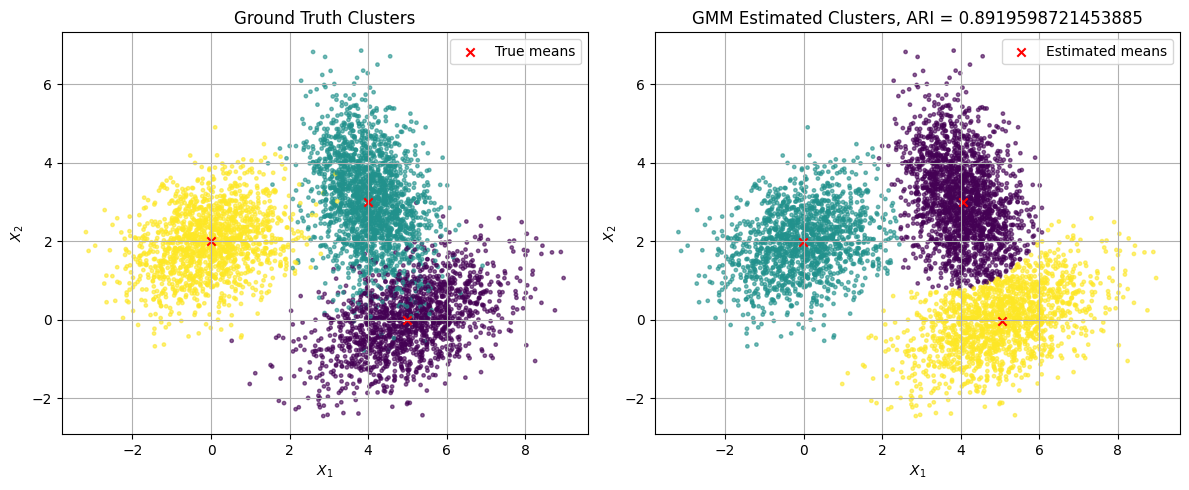

In [8]:
plt.figure(figsize=(12, 5))

# Ground Truth
plt.subplot(1, 2, 1)
plt.scatter(X_samp[:, 0], X_samp[:, 1], c=Z_samp, cmap="viridis", s=6, alpha=0.6)
plt.scatter(true_mus[:, 0], true_mus[:, 1], marker='x', c='red', label='True means')
plt.title("Ground Truth Clusters")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.legend()
plt.grid(True)

# Estimated Clusters
plt.subplot(1, 2, 2)
plt.scatter(X_samp[:, 0], X_samp[:, 1], c=pred_labels, cmap="viridis", s=6, alpha=0.6)
plt.scatter(np.array(mus)[:, 0], np.array(mus)[:, 1], marker='x', c='red', label='Estimated means')
plt.title(f"GMM Estimated Clusters, ARI = {ari_evol[-1]}")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#### Question 5:

**summary:** There is no clear distinct clusters in the 2D scatter plot. We can see a shabby 'U' shape, making think of at least 2 clusters, possibly more, with high overlapping rate. We also see some lonely outliers, that we could discard with simple preprocessing to make the learning process smoother.
Overall, we can guess that the EM-algorithm will struggle estimating nice clusters, because the dataset is way more dirty than the one above.

In [9]:
!ls -al "/content/drive/MyDrive/Colab_Notebooks/MVA25-26/Computational_Statistics/TPs"
current_path = "/content/drive/MyDrive/Colab_Notebooks/MVA25-26/Computational_Statistics/TPs/"
sys.path.append(current_path)
file_path = current_path + "WPP2024_Demographic_Indicators_Medium.csv.gz"

'''
To note:
The `.gz` extension indicates that the file is compressed, and can be read by any application able to work with .zip files.
But an added benefit is the possibility to directly read `.csv.gz` files without preliminary file decompression from many software environments
(e.g. fread function from "data.table" library in R, read_csv function from "panda" library in Python).
'''

total 19831
-rw------- 1 root root   151446 Oct 12 10:37 1.jpg
-rw------- 1 root root   185851 Oct 12 10:53 2.jpg
-rw------- 1 root root    83083 Oct 12 10:40 3.jpg
-rw------- 1 root root   389318 Oct 12 13:18 4.jpg
-rw------- 1 root root 16557272 Oct 24 10:12 WPP2024_Demographic_Indicators_Medium.csv.gz
-rw------- 1 root root  2104339 Oct 12 13:24 Yannael_BOSSARD_TP1.ipynb
-rw------- 1 root root   833743 Nov  1 23:43 Yannael_BOSSARD_TP2.ipynb


'\nTo note:\nThe `.gz` extension indicates that the file is compressed, and can be read by any application able to work with .zip files.\nBut an added benefit is the possibility to directly read `.csv.gz` files without preliminary file decompression from many software environments \n(e.g. fread function from "data.table" library in R, read_csv function from "panda" library in Python).\n'

/tmp/ipython-input-1587966112.py:11: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, compression='gzip')


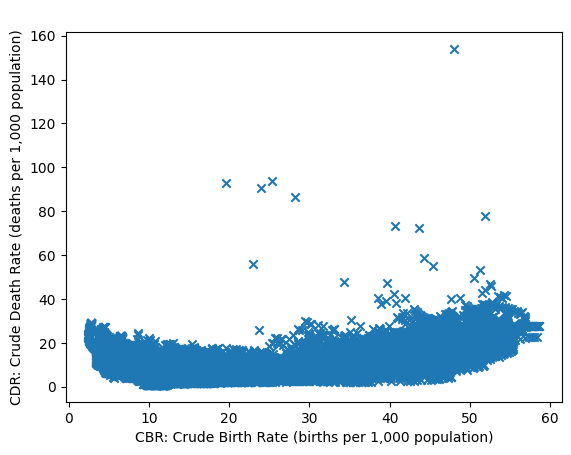

In [10]:
# source used:
# Database : https://population.un.org/wpp/downloads?folder=Standard%20Projections&group=CSV%20format
# open csv.gz : https://stackoverflow.com/questions/39645804/open-a-csv-gz-file-in-python-and-print-first-100-rows

import gzip
import csv
import json
import pandas as pd


df = pd.read_csv(file_path, compression='gzip')
subset = df[['CBR', 'CDR']].dropna() # focus on column CBR and CDR
CBR, CDR = subset['CBR'], subset['CDR']

plt.figure()
plt.scatter(CBR, CDR,marker='x')
plt.xlabel('CBR: Crude Birth Rate (births per 1,000 population)')
plt.ylabel('CDR: Crude Death Rate (deaths per 1,000 population)')
plt.title(" ")
plt.show()


#### Question 6:

**summary:** The clustering is quite unstable, and provide different results at each run, as expected because of the shabby distribution of the data. Moreover, the algorithm is implemented to be a direct application of the basic EM theory, but I did not try to optimize the computation efficiency, leading to very slow running time. This prevent the use of redundant execution to do statistics results instead of one shot results. However, a trend with one consistant cluster on the left (11,11) and one on the right (40,16), plus one cluster in the middle either capturing the global remaining samples, or being compact in the middle. Interpretation:

*   1st cluster with (CBR:≃11,CDR:≃11) (e.g. Could be a stable populations with long living people and low birth rate (developped country))

*   2nd cluster with (CBR:≃25,CDR:≃8) (e.g. Could be a recently developped country where the recent wealth increased life expectancy (low CDR), but still high birth rate. However the CDR is the lowest, so the population might be younger than for cluster 1)

*   3rd cluster with (CBR:≃41,CDR:≃16) (e.g. Could be a poor population with low life expectancy but compense by high fertility (high CBR))




mus =  [array([21.6584595 ,  7.64405382]), array([10.52835639, 11.31217556]), array([42.71363026, 16.24905926])]


/tmp/ipython-input-1291992430.py:30: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_conc[:, 0], X_conc[:, 1], cmap="viridis", s=6, alpha=0.6)
/tmp/ipython-input-1291992430.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


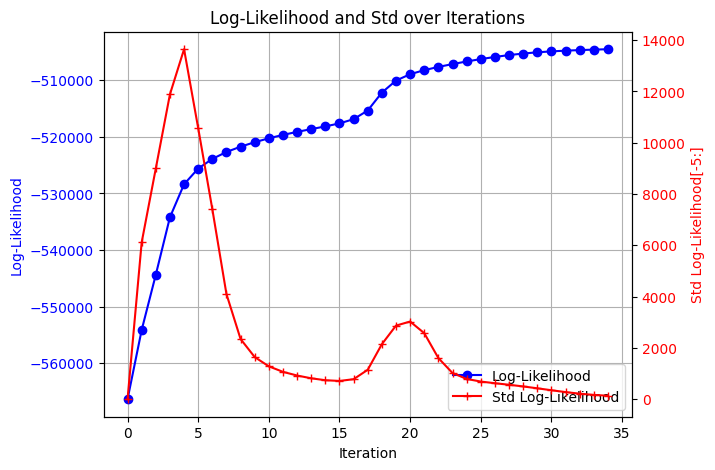

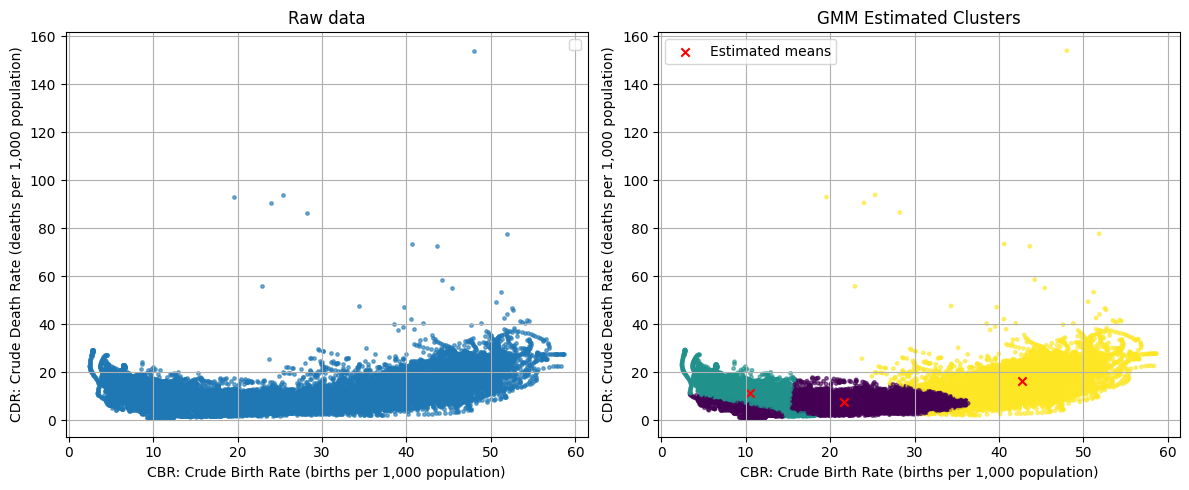

In [11]:
np.random.seed(9)
X_conc = np.array([CBR, CDR])
X_conc = np.transpose(X_conc)
alphas, mus, sigmas, log_likelihoods, std_loglikelihood, ari_evol, pred_labels = gmm_EM(X_conc, m=3, max_iter=35)
print("mus = ", mus)

iterations = np.arange(len(log_likelihoods))

plt.figure(figsize=(15, 5))
# Loglikelihood & std(log_likelihoods[-5:])
ax1 = plt.subplot(1, 2, 1)
ln1 = ax1.plot(iterations, log_likelihoods, color='blue', marker='o', label='Log-Likelihood')
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Log-Likelihood", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)
ax2 = ax1.twinx()
ln2 = ax2.plot(iterations, std_loglikelihood, color='red', marker='+', label='Std Log-Likelihood')
ax2.set_ylabel("Std Log-Likelihood[-5:]", color='red')
ax2.tick_params(axis='y', labelcolor='red')
lns = ln1 + ln2
labels = [l.get_label() for l in lns]
ax1.legend(lns, labels, loc='lower right')

ax1.set_title("Log-Likelihood and Std over Iterations")

plt.figure(figsize=(12, 5))
# Raw data
plt.subplot(1, 2, 1)
plt.scatter(X_conc[:, 0], X_conc[:, 1], cmap="viridis", s=6, alpha=0.6)
plt.title("Raw data")
plt.xlabel('CBR: Crude Birth Rate (births per 1,000 population)')
plt.ylabel('CDR: Crude Death Rate (deaths per 1,000 population)')
plt.legend()
plt.grid(True)

# Estimated Clusters
plt.subplot(1, 2, 2)
plt.scatter(X_conc[:, 0], X_conc[:, 1], c=pred_labels, cmap="viridis", s=6, alpha=0.6)
plt.scatter(np.array(mus)[:, 0], np.array(mus)[:, 1], marker='x', c='red', label='Estimated means')
plt.title(f"GMM Estimated Clusters")
plt.xlabel('CBR: Crude Birth Rate (births per 1,000 population)')
plt.ylabel('CDR: Crude Death Rate (deaths per 1,000 population)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



#### Question 7:

**summary:** We see that in the BIC evolution figure that the BIC values keep decreasing with the number of clusters increasing. This can be explain by noisy dense distribution, where GMM cannot fully explain/fit the distribution. Hence, the more cluster, the more overfitting we are, so taking the absolute minimum value doesn't make sens here (it would in the nice distribution above (question 2)). **Instead, we should look for an elbow, like the one at m=5**. This would imply 5 clusters (5 types of (CBR/CDR) behavior), but my history/sociology knowledge is too little to be able to explain why 5 (this goes beyong the simple poor/in-development/developped vision of population).

(btw, the red vertical line highlights argmax, not argmin, so the worst number of cluster, not the best, but re-running takes a couple of hours on Colab, plus unstable connection ..)

In [12]:
def BIC_criterion(loglikelihood, X, m):
    '''
    BIC =  -loglikelihood + (df(m)*log n)/2
    with df the degree of freedom of the mixture:
      - mixture weights: m-1  (-1 because sum to 1)
      - means:   m*d (m clusters * dimension (d features))
      - covs:    m * d(d+1)/2  (because symmetric -> sum the upper triangle)
    '''
    n, d = X.shape
    df = (m-1) + (m*d) + m*(d*(d+1)/2)
    return -loglikelihood + 0.5*df*np.log(n)


def mixture_pdf(x, alphas, mus, sigmas):
    '''
    p(x) = sum_j alpha_j * N(x | mu_j, sigmas_j)
    '''
    return sum(alphas[j] * gaussian_pdf(x, mus[j], sigmas[j]) for j in range(len(alphas)))


def pdf_contour(X, alphas, mus, sigmas, nx=200,ny=200,padding=0.05):
    '''
    We compute the mixture probability density p(x) at many points arranged on a rectangular grid

    Returns xx, yy, ZZ where ZZ[i,j] = p([xx[i,j], yy[i,j]]).

    '''
    x1, x2 = X[:, 0], X[:, 1]
    r1,r2 = x1.max() - x1.min(),x2.max() - x2.min()

    # bound the grid for nicer visu
    x_min, x_max = x1.min() - padding*r1, x1.max() + padding*r1
    y_min, y_max = x2.min() - padding*r2, x2.max() + padding*r2

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),np.linspace(y_min, y_max, ny)) #grid the 2D space
    ZZ = np.empty_like(xx, dtype=float) # Compute the pdf at each point

    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            x = np.array([xx[i, j], yy[i, j]])
            ZZ[i, j] = mixture_pdf(x, alphas, mus, sigmas)
    return xx, yy, ZZ


def display_contour_GMM(X_conc, alphas, mus, sigmas):
  xx, yy, ZZ = pdf_contour(X_conc, alphas, mus, sigmas)
  plt.figure(figsize=(7,6))
  plt.scatter(X_conc[:,0], X_conc[:,1], s=6, alpha=0.2, label="data")
  cs = plt.contour(xx, yy, ZZ, levels=10)
  mus = np.array(mus)
  plt.scatter(mus[:,0], mus[:,1], marker='x', s=80, c='red', label="component means")
  plt.xlabel('CBR: Crude Birth Rate (births per 1,000 population)')
  plt.ylabel('CDR: Crude Death Rate (deaths per 1,000 population)')
  plt.legend()
  plt.grid(True)
  plt.show()

 Working on m=1 (1/9)


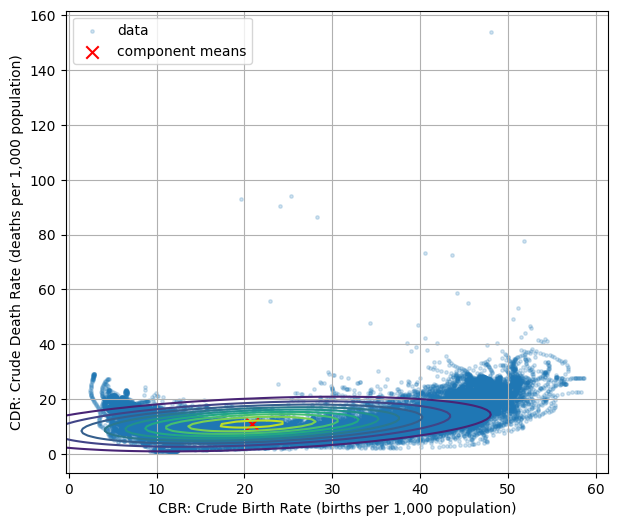

 Working on m=2 (2/9)


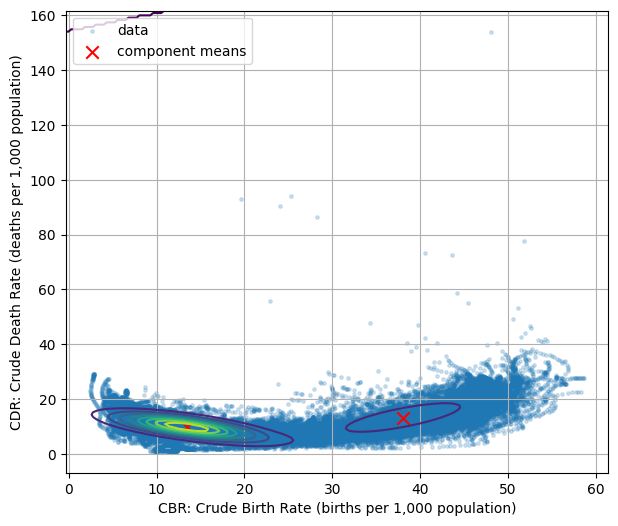

 Working on m=3 (3/9)


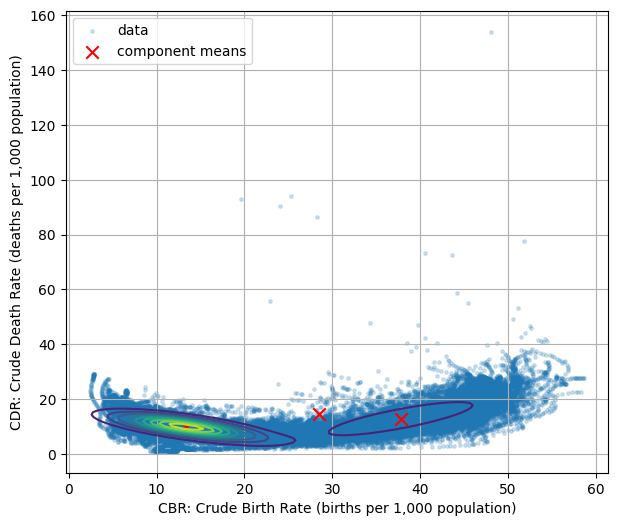

 Working on m=4 (4/9)


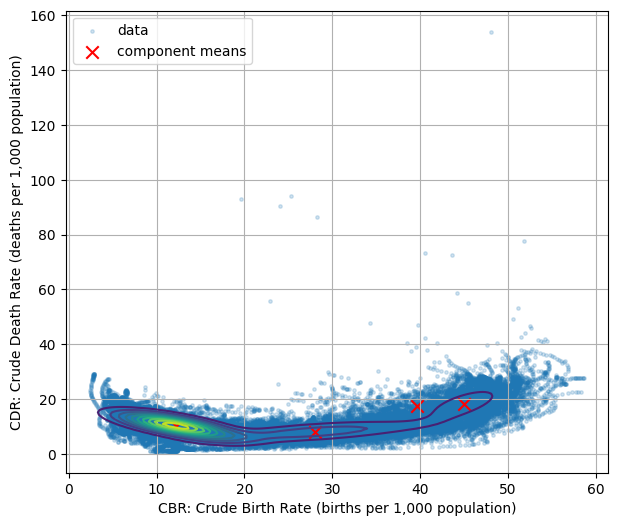

 Working on m=5 (5/9)


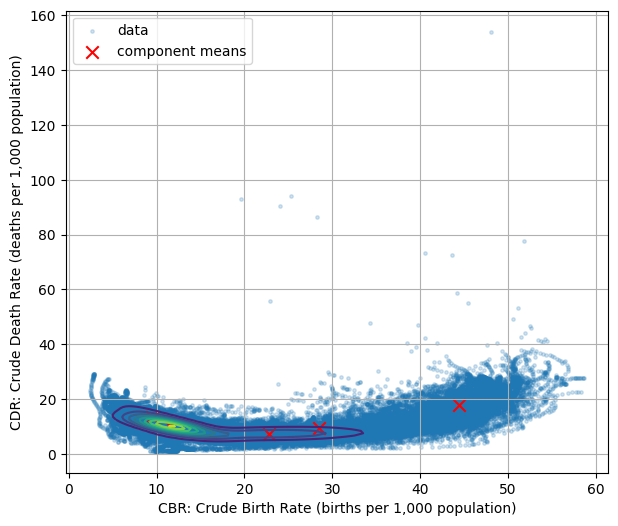

 Working on m=7 (6/9)


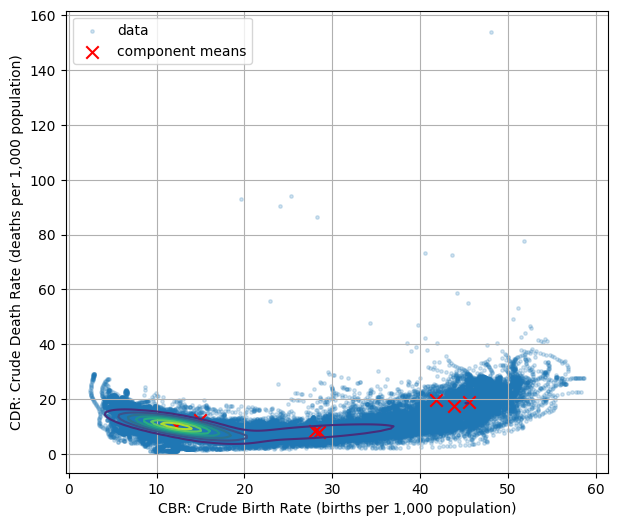

 Working on m=10 (7/9)


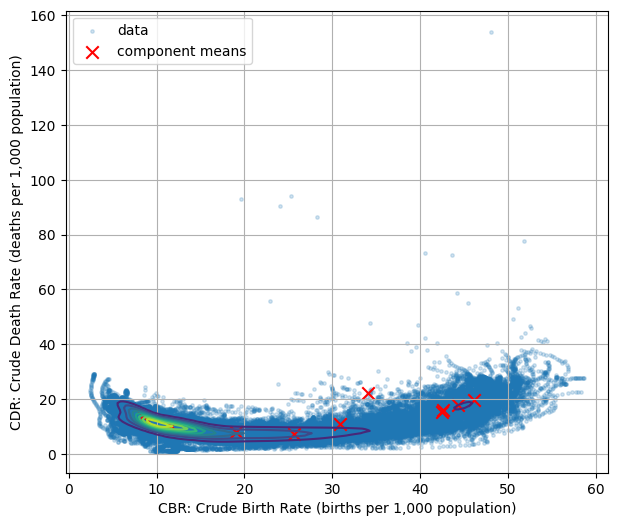

 Working on m=12 (8/9)


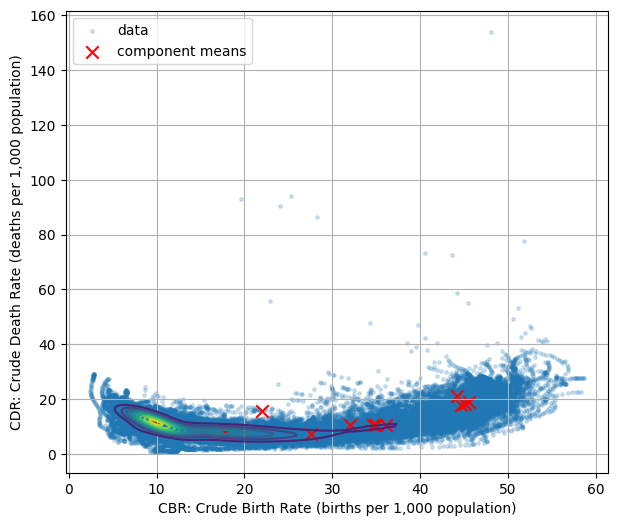

 Working on m=15 (9/9)


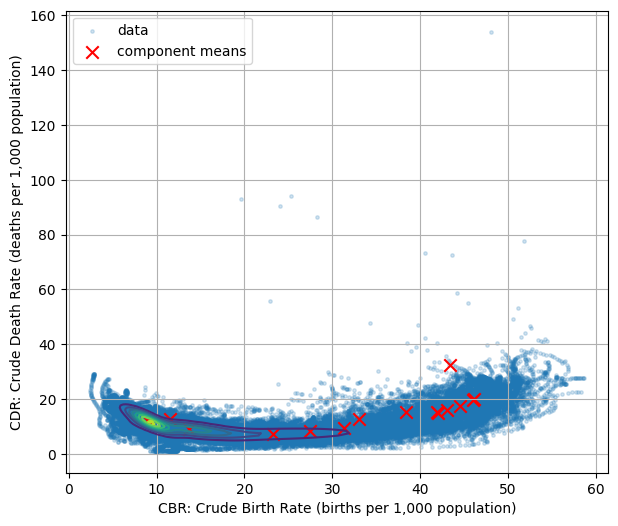

Best number of clusters: 1


In [13]:




m_list = [1,2,3,4,5,7,10,12,15]
#m_list = [3,4]
bic_list = []
for im, m in enumerate(m_list):
  print(f" Working on m={m} ({im+1}/{len(m_list)})")
  alphas, mus, sigmas, log_likelihoods, std_loglikelihood, ari_evol, pred_labels = gmm_EM(X_conc, m=m, max_iter=15)
  loglikelihoods = log_likelihoods[-1]
  bic = BIC_criterion(loglikelihoods, X_conc, m)
  bic_list.append(bic)
  display_contour_GMM(X_conc, alphas, mus, sigmas)


best_m = m_list[np.argmin(bic_list)]
print(f"Best number of clusters: {best_m}")






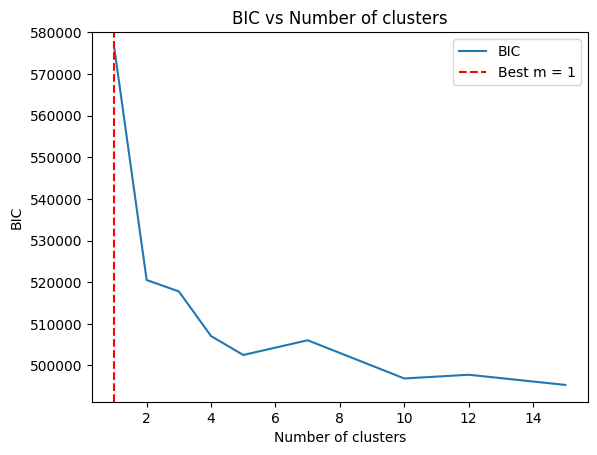

In [14]:
plt.figure()
plt.plot(m_list,bic_list,label="BIC")
plt.xlabel("Number of clusters")
plt.ylabel("BIC")
plt.title("BIC vs Number of clusters")
plt.axvline(x=best_m, color='r', linestyle='--', label=f'Best m = {best_m}')
plt.legend()
plt.show()


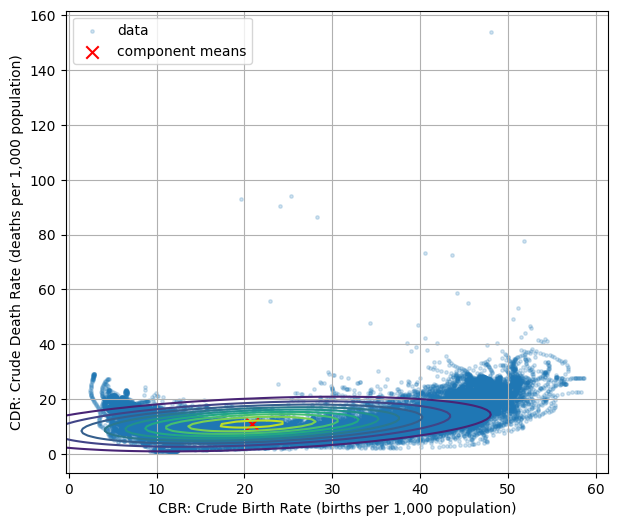

In [15]:
alphas, mus, sigmas, log_likelihoods, std_loglikelihood, ari_evol, pred_labels = gmm_EM(X_conc, m=best_m, max_iter=30)

display_contour_GMM(X_conc, alphas, mus, sigmas)


## Exercice 3: Importance Sampling
## 3.A:

#### Question 1:

I use the normalized important weights to compute the Importance sampling

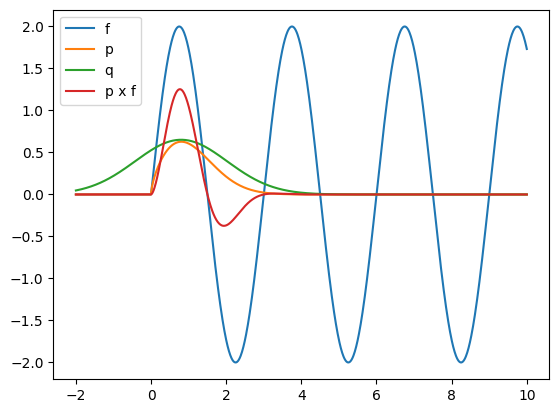

In [16]:
def indicator_Rplus(x):
  mask_Rplus = x >= 0
  mask_Rplus = mask_Rplus.astype(int)
  return mask_Rplus

def supp_f(x):
  mask_Rplus = indicator_Rplus(x)
  return 2*np.sin(np.pi*x/1.5)*mask_Rplus

def distr_p(x):
  mask_Rplus = indicator_Rplus(x)
  x = x*mask_Rplus
  dp = x**(1.65-1)*np.exp(-0.5*x**2)
  return dp#*mask_Rplus

def distr_q(x,mu=0.8,sigma_s=1.5):
  dq = (2/np.sqrt(2*np.pi*sigma_s))*np.exp(((mu-x)**2)/(-2*sigma_s))
  return dq

def importance_sampling(x,mu):
  n = len(x)
  w = distr_p(x)/distr_q(x,mu)
  norm_w = np.sum(w)/n
  Ep_f = (w/norm_w)*supp_f(x)
  return np.sum(Ep_f)/n


def groundtruth_num_integral(x):
  '''
  Numerical Integral of f(x) over [0,max(x)],
  use as a proxy of ground truth of Ep_f
  '''
  n_rect = 10000
  x_rplus = np.linspace(0,max(x),n_rect)
  dx = max(x) / (n_rect-1)
  fx = supp_f(x_rplus)
  px = distr_p(x_rplus)
  num = np.sum(fx*px)*dx
  den = np.sum(px)*dx # need to normalize distri_p
  return num/den

def sample_from_q(N,mu,sigma_s=1.5):
  '''
  Generate i.i.d. random variables (X1, . . . ,Xn) from q in order to approximate Eq[f(X)]
  with Monte Carlo integration
  '''
  maxiter = 0
  samples = np.random.normal(mu, np.sqrt(sigma_s), size=2*N) # q distribution
  samples = samples[samples >= 0]  # discard samples <0
  if len(samples) >= N:
    return samples[:N]
  while len(samples) < N and maxiter < 100:
    samples = np.random.normal(mu, np.sqrt(sigma_s), size=N)
    samples = samples[samples >= 0]  # discard samples <0
    maxiter += 1
  if maxiter == 100:
    return samples # It's okay if it's not exactly N samples..
  return samples[:N]


x = np.linspace(-2,10,1000)
plt.figure()
plt.plot(x,supp_f(x),label="f")
plt.plot(x,distr_p(x),label="p")
plt.plot(x,distr_q(x),label="q")
plt.plot(x,distr_p(x)*supp_f(x),label="p x f")
plt.legend()
plt.show()

#### Question2:

**summary:** As expected, when we increase the number of sample per k, we divide the variance of E_p[f(x)] per k. We see that with only 10 samples, we have an error of less than 5%, which falls to 0.1% with 1e4 samples (compared to basic numerical integration).

mu=0.8, N=10: mean=0.8237, var=0.1522, error = 5.407 (vs Numerical Integration)
mu=0.8, N=100: mean=0.7674, var=0.0125, error = 0.225 (vs Numerical Integration)
mu=0.8, N=1000: mean=0.7712, var=0.0014, error = 0.161 (vs Numerical Integration)
mu=0.8, N=10000: mean=0.7697, var=0.0002, error = 0.003 (vs Numerical Integration)


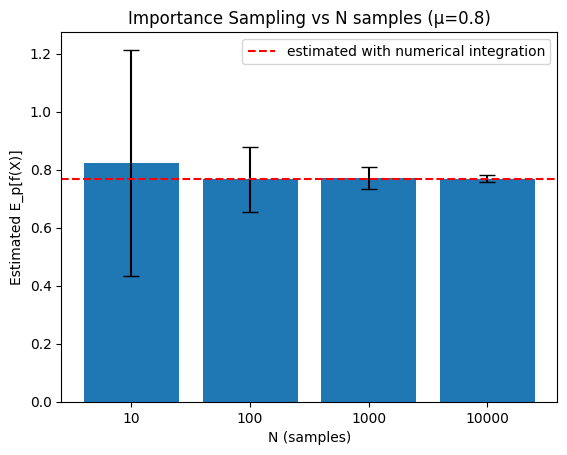

In [17]:

def run_question2(N,gt_Ep_f, mu):
  n_trials = 100
  pool_estim_Ep_f = np.zeros(n_trials)
  for i in range(n_trials):
    x = sample_from_q(N,mu,sigma_s)
    pool_estim_Ep_f[i] = importance_sampling(x,mu=mu)

  mean_estim_Ep_f = np.mean(pool_estim_Ep_f)
  var_estim_Ep_f = np.var(pool_estim_Ep_f)
  print(f"mu={mu}, N={N}: mean={mean_estim_Ep_f:.4f}, var={var_estim_Ep_f:.4f}, error = {abs(gt_Ep_f-mean_estim_Ep_f)*100:.3f} (vs Numerical Integration)")
  return mean_estim_Ep_f,var_estim_Ep_f


N_list = [1e1,1e2,1e3,1e4]
mu = 0.8
sigma_s = 1.5

gt_Ep_f = groundtruth_num_integral(x)

mean_estim_Ep_f_list,var_estim_Ep_f_list = [],[]
for N in N_list:
  N = int(N)
  mean_estim_Ep_f,var_estim_Ep_f = run_question2(N,gt_Ep_f, mu=mu)
  mean_estim_Ep_f_list.append(mean_estim_Ep_f)
  var_estim_Ep_f_list.append(var_estim_Ep_f)

## Plot
plt.figure()
xpos = np.arange(len(N_list))
labels = [f"{int(N):d}" for N in N_list]
yerr = np.sqrt(var_estim_Ep_f_list)
plt.bar(xpos, mean_estim_Ep_f_list, yerr=yerr, capsize=6)
plt.xticks(xpos, labels)
plt.xlabel("N (samples)")
plt.ylabel("Estimated E_p[f(X)]")
plt.title(f"Importance Sampling vs N samples (μ={mu})")
plt.axhline(gt_Ep_f, linestyle='--',c='r',label="estimated with numerical integration")
plt.legend()
plt.show()



#### Question 3:

**summary:** We see that when the centers of mass of each distribution are far apart, barely overlapping, (meaning the importance density q is far from q*), the importance sampling provides very poor results, uncorrelated with the number of samples.
The log-scale plot of the importance weights shows that with μ=6, there are orders of magnitude between weights, and most of the weights contributes to nothing. This explain the poor estimation. Increasing N doesn't change much, becausealmost no samples are draw i region where p is non-almost-zero.

mu=6, N=10: mean=0.3341, var=1.7371, error = 43.548 (vs Numerical Integration)
mu=6, N=100: mean=0.0113, var=1.4594, error = 75.833 (vs Numerical Integration)
mu=6, N=1000: mean=-0.9671, var=0.6544, error = 173.672 (vs Numerical Integration)
mu=6, N=10000: mean=-0.1149, var=0.9830, error = 88.454 (vs Numerical Integration)


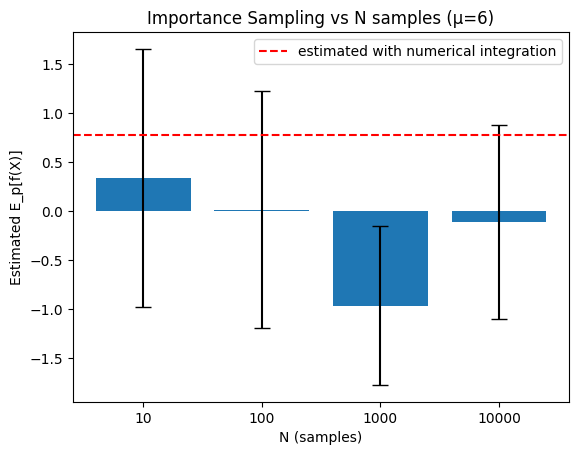

In [18]:
N_list = [1e1,1e2,1e3,1e4]
mu = 6
sigma_s = 1.5

gt_Ep_f = groundtruth_num_integral(x)

mean_estim_Ep_f_list,var_estim_Ep_f_list = [],[]
for N in N_list:
  N = int(N)
  mean_estim_Ep_f,var_estim_Ep_f = run_question2(N,gt_Ep_f, mu=mu)
  mean_estim_Ep_f_list.append(mean_estim_Ep_f)
  var_estim_Ep_f_list.append(var_estim_Ep_f)

## Plot
plt.figure()
xpos = np.arange(len(N_list))
labels = [f"{int(N):d}" for N in N_list]
yerr = np.sqrt(var_estim_Ep_f_list)
plt.bar(xpos, mean_estim_Ep_f_list, yerr=yerr, capsize=6)
plt.xticks(xpos, labels)
plt.xlabel("N (samples)")
plt.ylabel("Estimated E_p[f(X)]")
plt.title(f"Importance Sampling vs N samples (μ={mu})")
plt.axhline(gt_Ep_f, linestyle='--',c='r',label="estimated with numerical integration")
plt.legend()
plt.show()


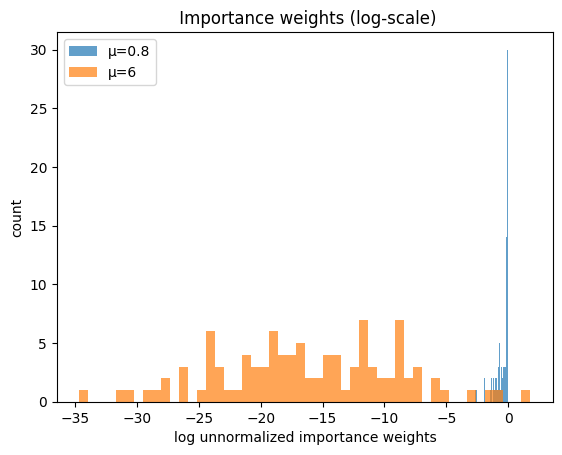

In [19]:
# Compare importance weights for both means
N = 100
x1 = sample_from_q(N, mu=0.8)
x2 = sample_from_q(N, mu=6)
w1 = distr_p(x1) / distr_q(x1, mu=0.8)
w2 = distr_p(x2) / distr_q(x2, mu=6)

# We have to use log scale, because w2 (importance weights for μ=6) are essentially 0
plt.figure()
plt.hist(np.log(w1), bins=50, alpha=0.7, label="μ=0.8")
plt.hist(np.log(w2), bins=50, alpha=0.7, label="μ=6")
plt.xlabel("log unnormalized importance weights")
plt.ylabel("count")
plt.title(" Importance weights (log-scale)")
plt.legend()
plt.show()

## 3.B:

#### Question 4:


In [20]:
print("todo")

todo


### Used References:

Discrete distribution: https://en.wikipedia.org/wiki/Inverse_transform_sampling

EM:
https://lmbp.uca.fr/~latouche/mva/IntroductiontoProbabilisticGraphicalModelsMVA.html

https://medium.com/@zhe.feng0018/coding-gaussian-mixture-model-and-em-algorithm-from-scratch-f3ef384a16ad

Sampling: /
